# Часть 1
 - SLURM скрипт лежит `hw4 -> run_velvet.slurm`
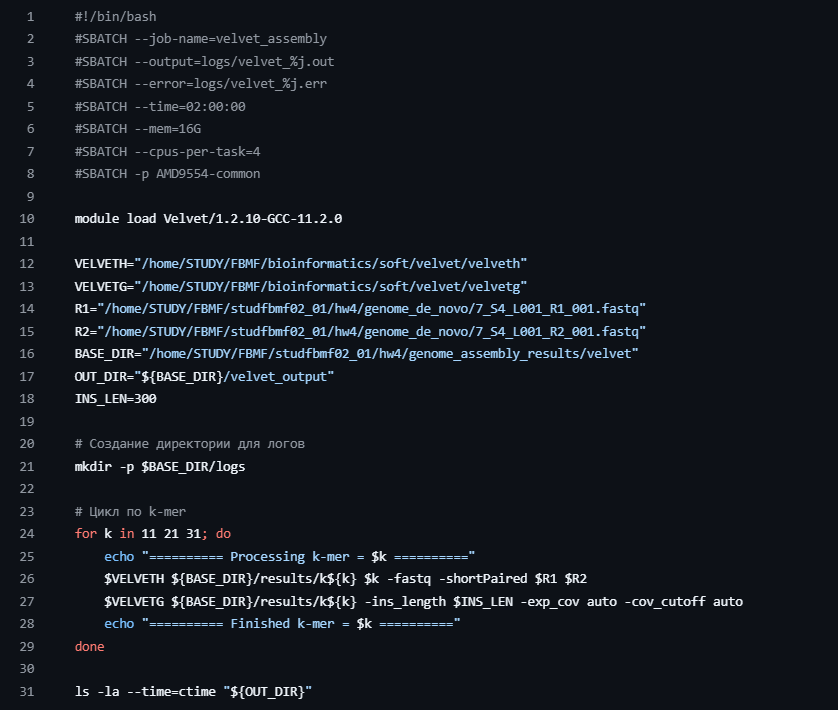 

 - Скриншот папки на сервере c созданными файлами сборки velvet
 
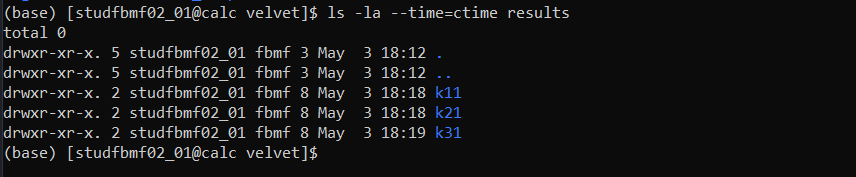

# Часть 2
QUAST-отчет о сравнении сборок лежит `hw4 -> assembly_analysis -> report.html`

Здесь будут приведены скриншоты QUAST-отчета

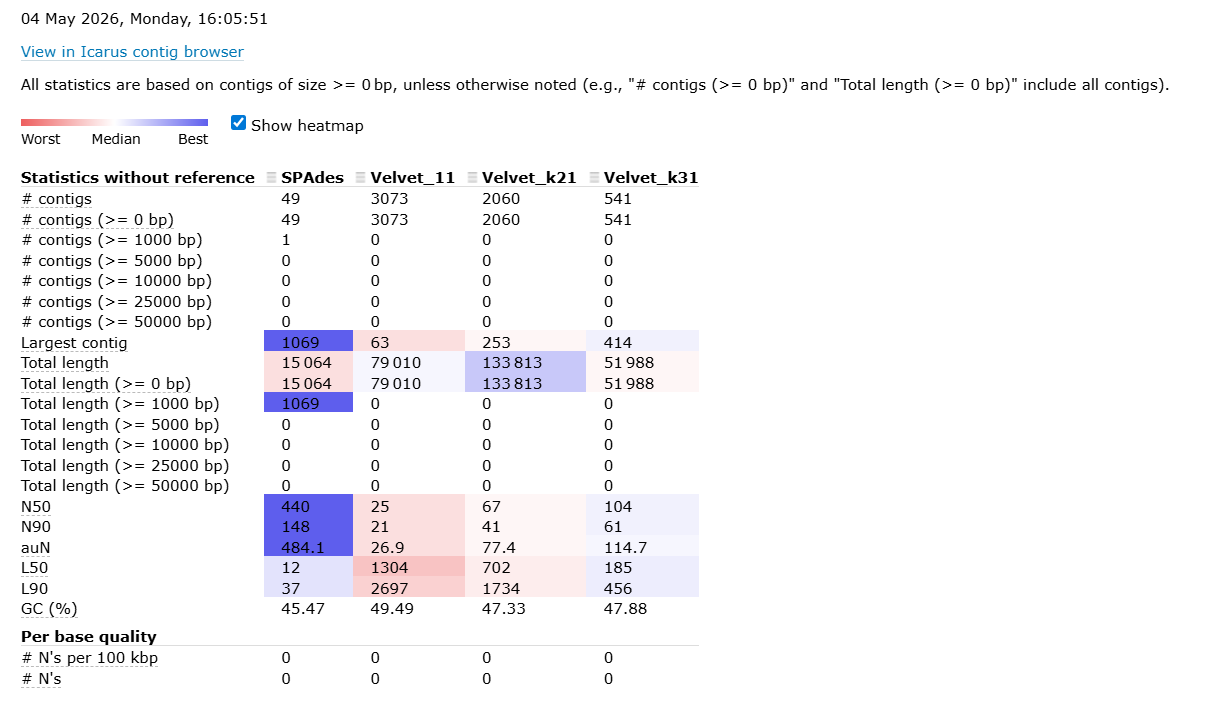

 - SPAdes показал наилучшие результаты: у него самое маленькое количество контигов и самые длинные участки
     - Largest contig (1069): Самый длинный фрагмент у SPAdes (1069 п.н.) значительно длиннее, чем у любого Velvet (максимум 414 п.н. при k31)
     - Количество контигов (49): Чем меньше фрагментов при достаточной общей длине, тем более цельной является сборка. 49 контигов против 3073 у Velvet_11
     - L50 (12): Для того чтобы собрать 50% генома, SPAdes потребовалось всего 12 самых крупных контигов
     - N50 (440): Половина всей длины сборки содержится в контигах длиной 440 п.н. и более. У SPAdes этот показатель выше, чем у Velvet-ов
 - Velvet выдает фрагментированную сборку, это особенно заметно у Velvet_k11 и Velvet_k21. С увеличением k-мера до 31 качество Velvet улучшается, но все равно уступает SPAdes

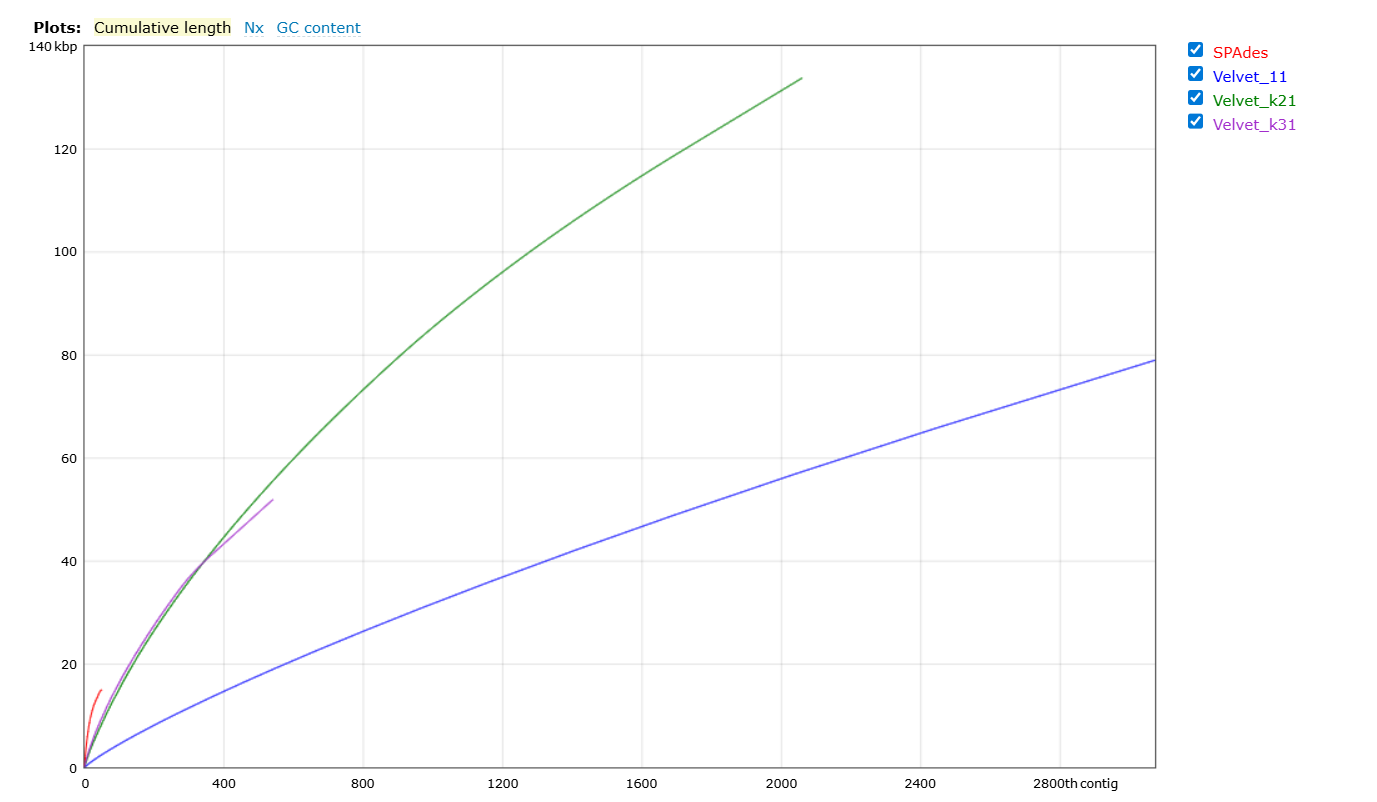

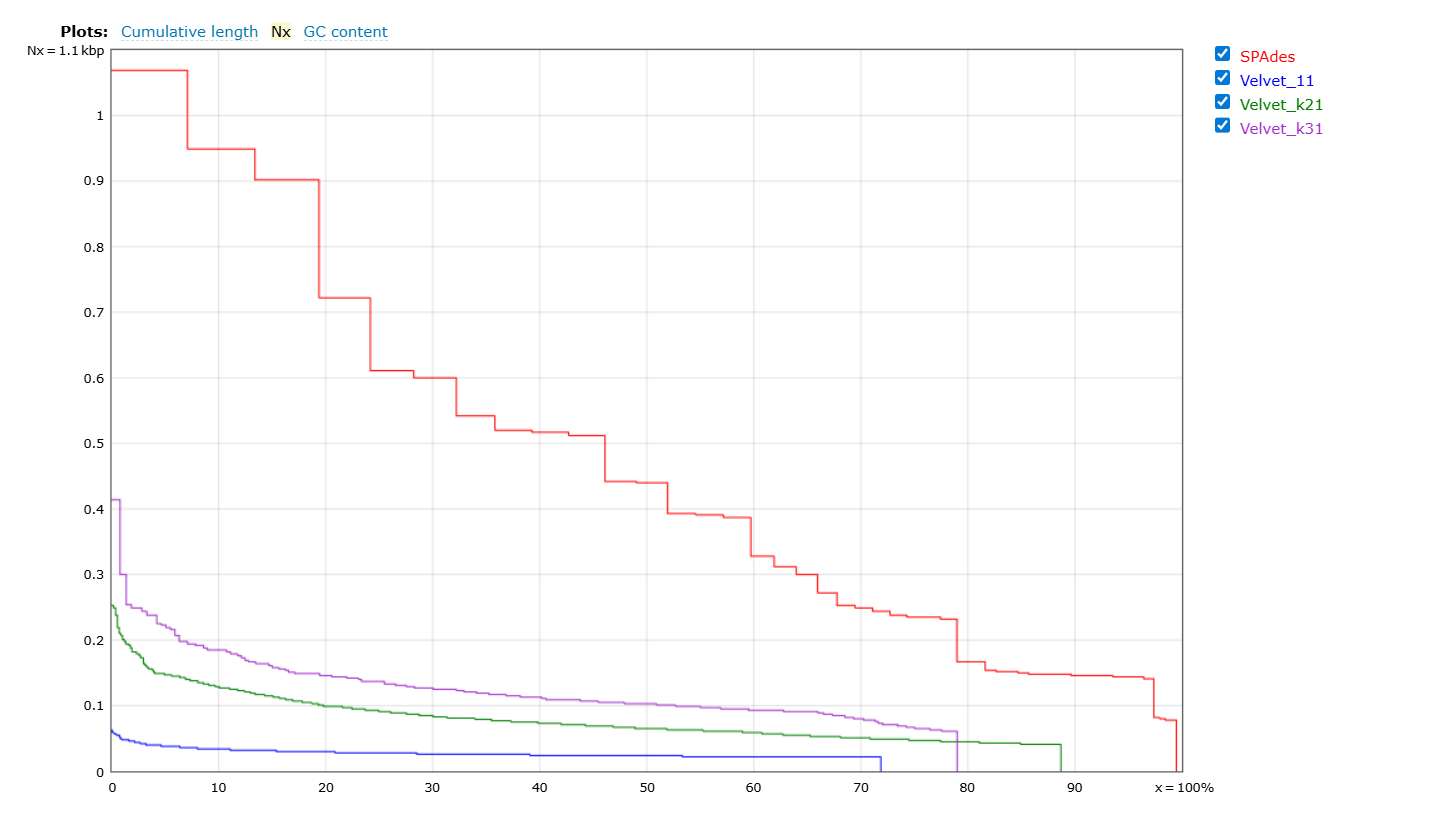

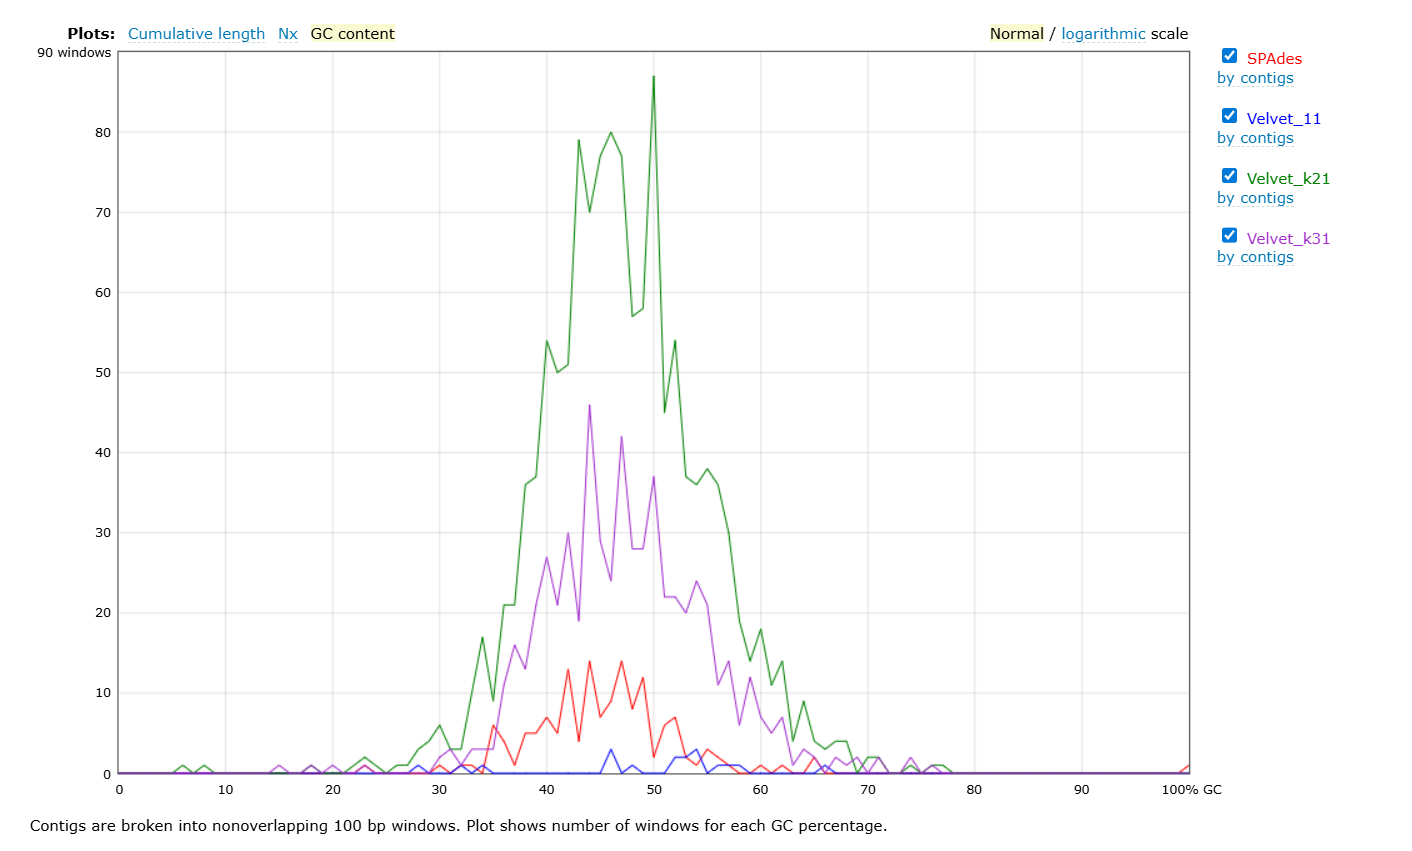

# Часть 3

Для улучшение существующих сборок применялись следующие действия
 - для SPAdes сделана предобработка ридов с помощью fastp: Удаление адаптеров (--detect_adapter_for_pe), обрезка низкокачественных оснований, удаление ридов короче 50 bp
 - для Velvet аналогичная предобработка ридов с помощью fastp, Отсечение коротких контигов (-min_contig_lgth 200), попытка увеличения k‑мер

SLURM скрипт лежит `hw4 -> run_velvet_upgrade.slurm`

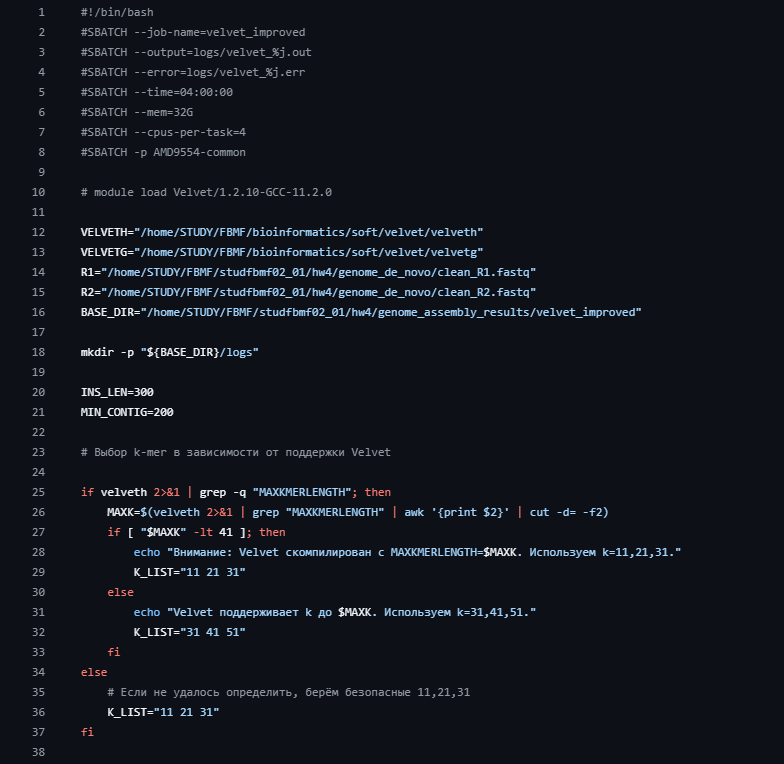
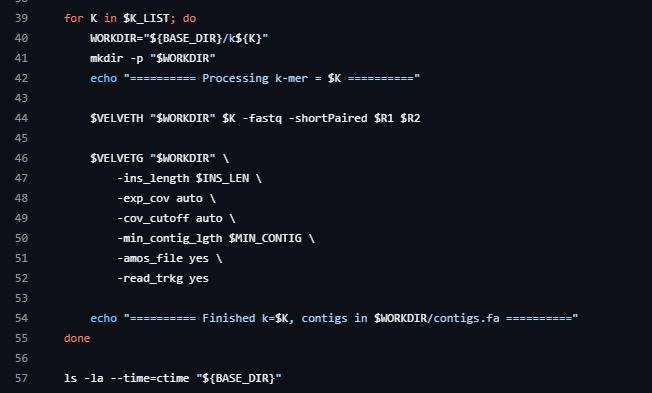

QUAST-отчет о сравнении сборок лежит `hw4 -> assembly_analysis_upgrades -> report.html`

Здесь будут приведены скриншоты QUAST-отчета

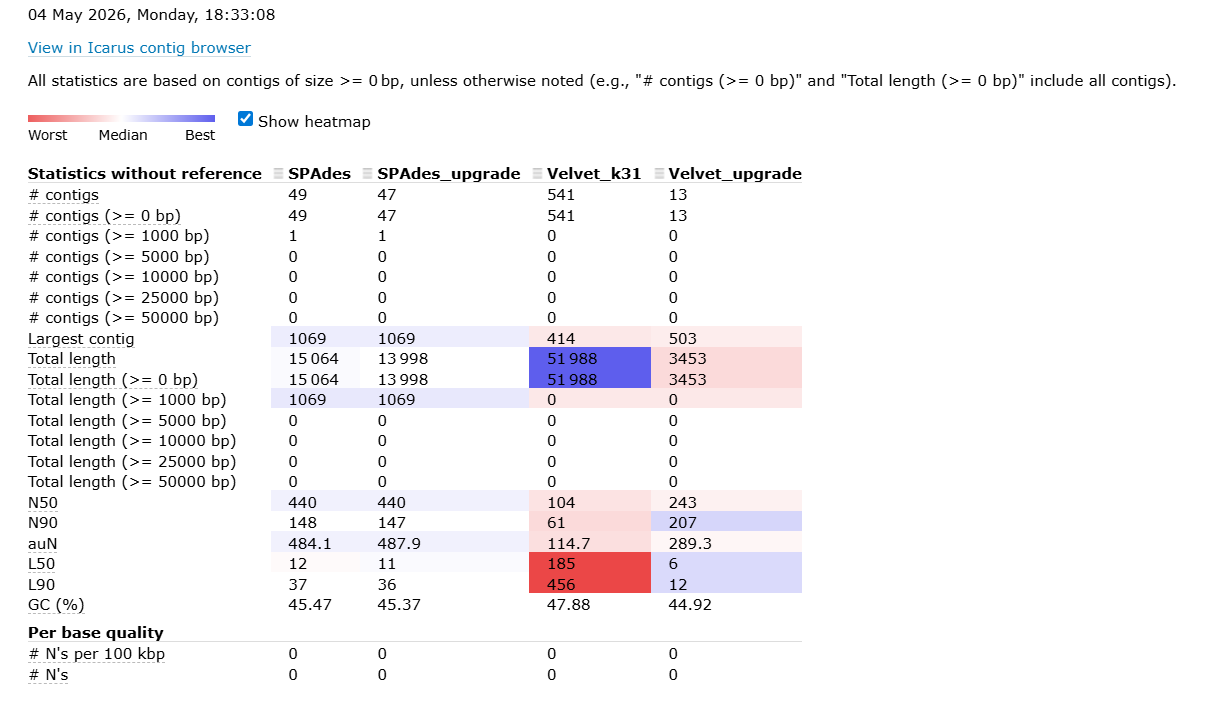

 - В случае SPAdes изменения не привели к значительному улучшению результатов
 - В случае Velvet видим сокращение числа контигов (541 -> 13), N50 вырос более чем в два раза (с 104 до 243), а L50 упал с 185 до 6, !НО! Используя фильтрацию -min_contig_lgth 200 Velvet просто удаляет сотни мелких фрагментов, которые раньше создавали видимость большой сборки, сейчас же сборка потеряла полноту и сжалась до 3.4 кб

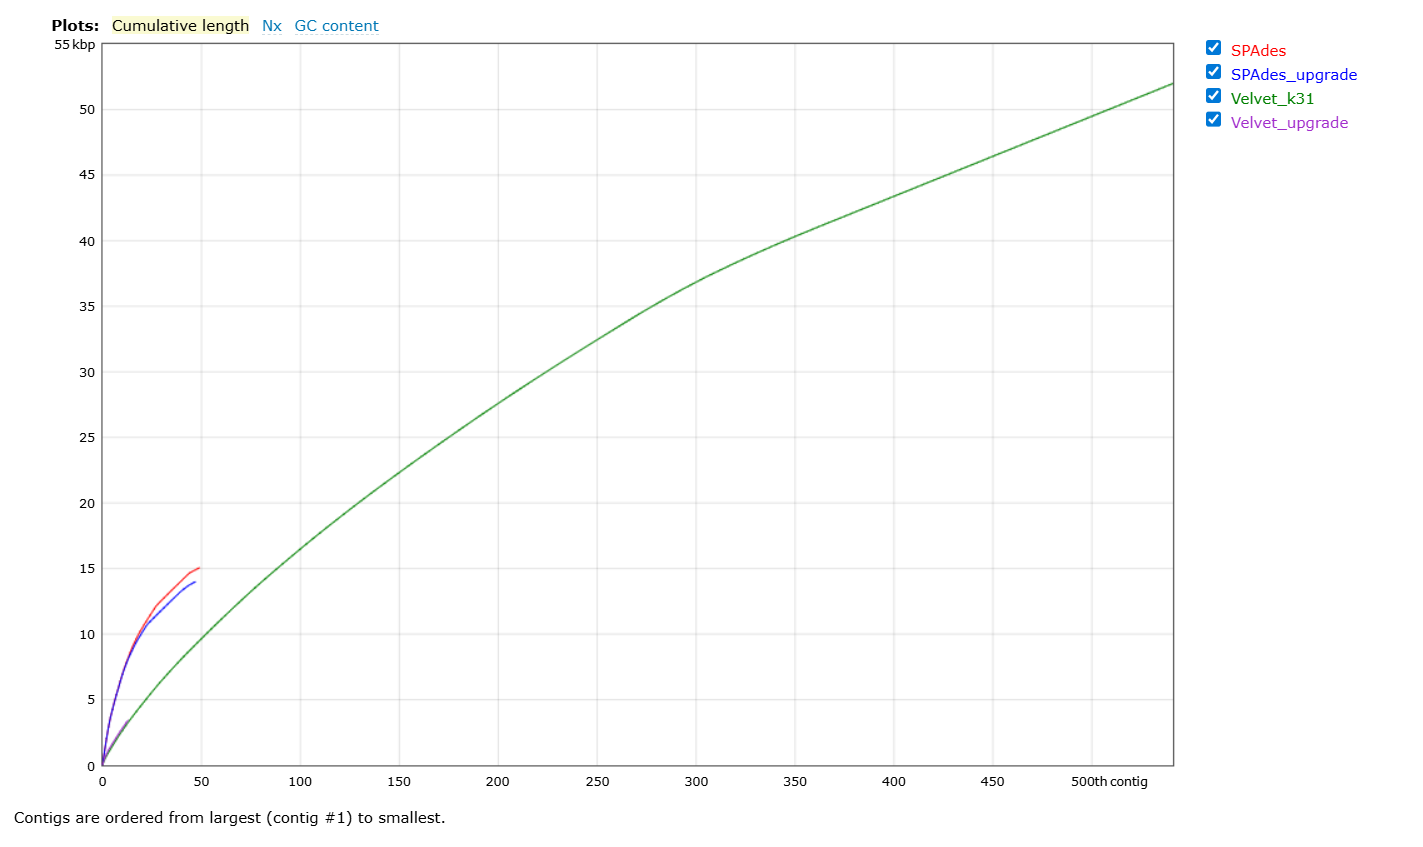

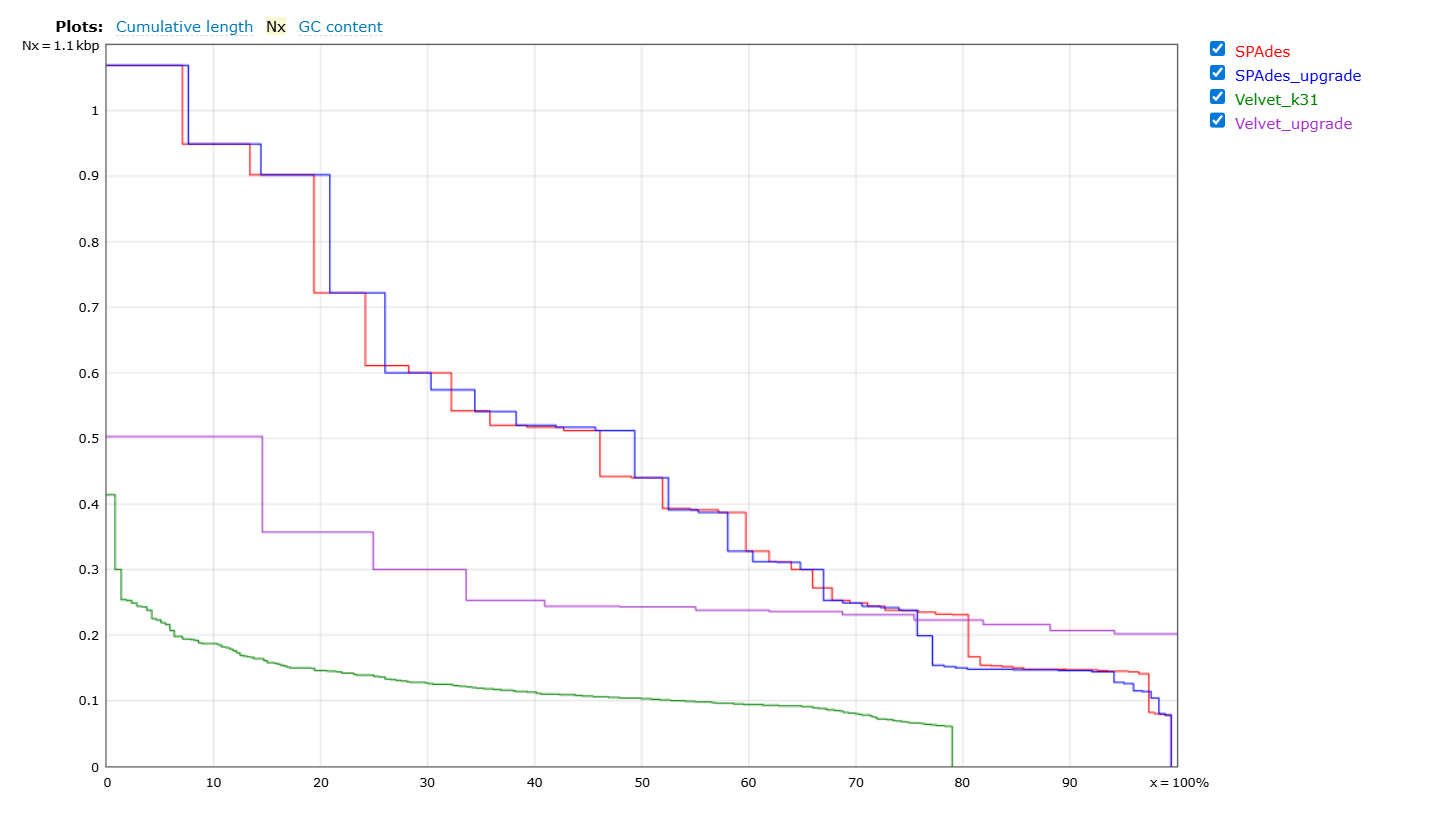

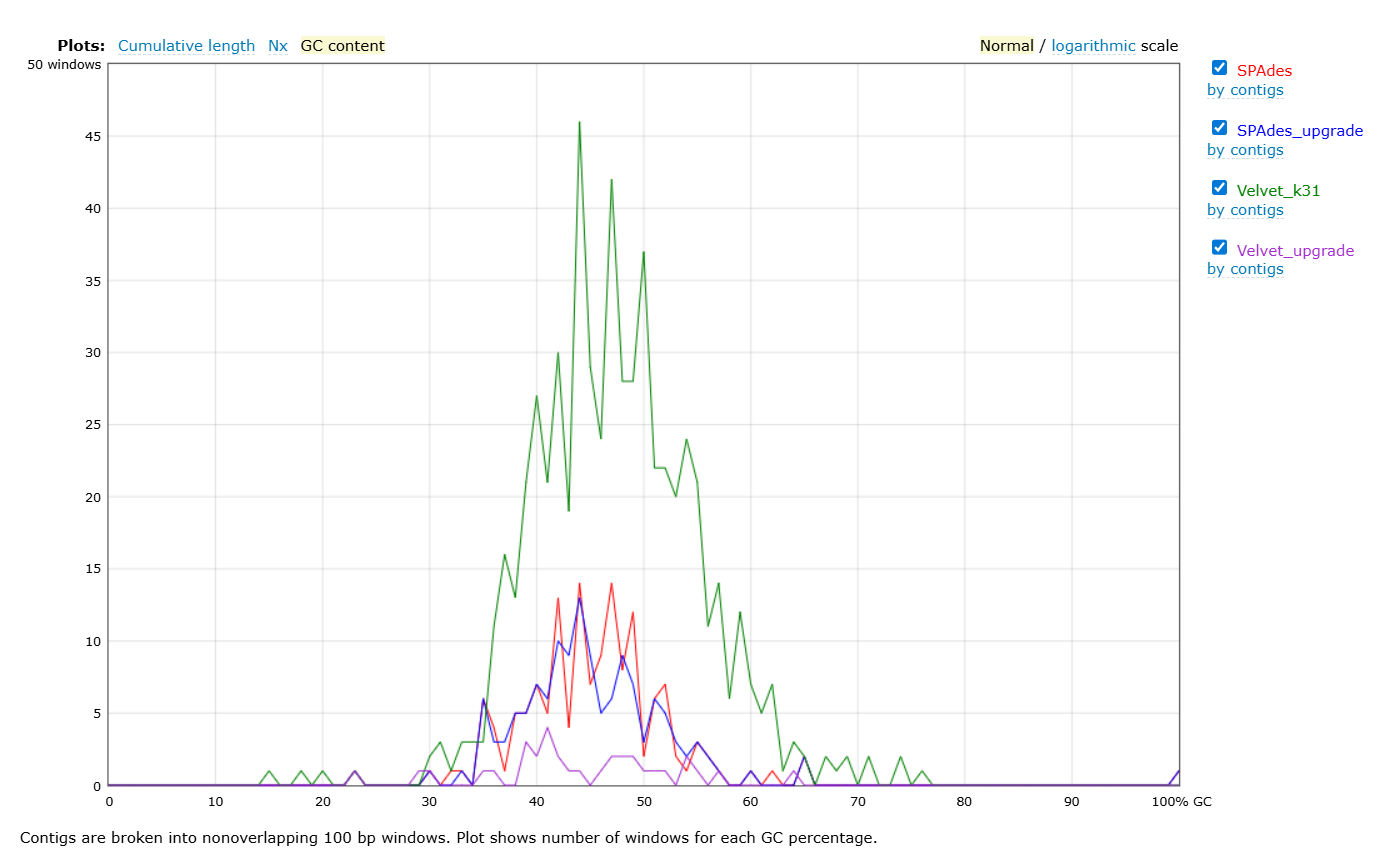

# Вывод
В результате работы выяснили, что в данном эксперименте SPAdes более устойчив к качеству входных данных и показывает лучшие результаты сборок. Для Velvet предобработка и фильтрация являются достаточно важными: без них сборка сильно фрагментирована, а после — теряет в полноте. Так же для Velvet значительное влияние оказывает выбор k-мер